In [4]:
from PIL import Image
from io import BytesIO
import torchvision.transforms as T
import requests, os 
import matplotlib.pyplot as plt 

In [2]:
results_path = os.path.join('results', '15_diffusion')

if not os.path.exists(results_path):
    os.makedirs(results_path) 

In [3]:
URL="https://github.com/geronimi73/3090_shorts/blob/main/assets/3.jpg?raw=True"

image = Image.open(BytesIO(requests.get(URL).content))

# Crop a 512x512 image from the center
# AE downsizes image by factor 32 dc-ae-f32c32-sana-1.0-diffusers
# -> image dimensions must be a multiple of 32!
image = T.CenterCrop(512)(image)
image.size

(512, 512)

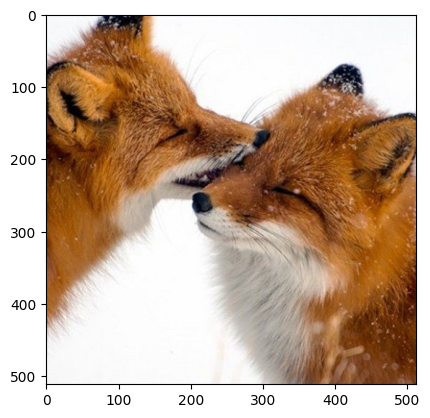

In [5]:
plt.imshow(image) 

In [7]:
import torch
from diffusers import AutoencoderDC

In [8]:
# use CUDA if we have, otherwise Apple Silicon will work too, CPU will be very slow probably
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
dtype = torch.bfloat16

In [9]:
# Load the Autoencoder which came with the first Sana release
# mit-han-lab/dc-ae-f32c32-sana-1.0-diffusers
dcae = AutoencoderDC.from_pretrained(
    "Efficient-Large-Model/Sana_600M_1024px_diffusers", 
    subfolder="vae", 
    torch_dtype=dtype
).to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/project/6095556/jxiang27/ai4fun/ai4fun/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.25G [00:00<?, ?B/s]

In [10]:
# Convert the image to a tensor and normalize mean and std.
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# convert, change dtype to bfloat16, and put on device 
latent = transform(image)[None].to(device).to(dtype)

# convert to latent
with torch.no_grad():
    latent = dcae.encode(latent).latent
latent.shape

torch.Size([1, 32, 16, 16])

In [11]:
with torch.no_grad():
    image_roundtrip = dcae.decode(latent).sample.to("cpu")

# Normalize autoencoder output back to 0-1 and transform to image
image_roundtrip = torch.clamp_(image_roundtrip[0,:], -1, 1)
image_roundtrip = image_roundtrip * 0.5 + 0.5
image_roundtrip = T.ToPILImage()(image_roundtrip.float())

In [13]:
image_roundtrip.size 

(512, 512)

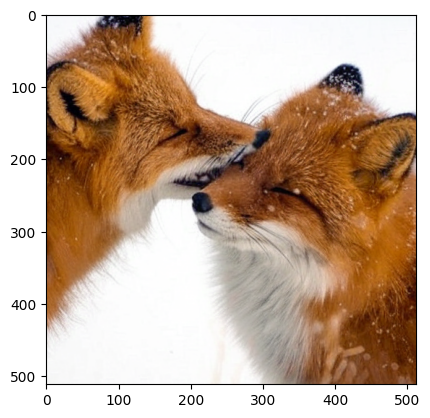

In [14]:
plt.imshow(image_roundtrip)

In [15]:
from transformers import Gemma2Model, GemmaTokenizerFast
import torch

dtype = torch.bfloat16
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

model_repo = "Efficient-Large-Model/Sana_600M_1024px_diffusers"

tokenizer = GemmaTokenizerFast.from_pretrained(
    model_repo, 
    subfolder="tokenizer", 
    torch_dtype=dtype
)

text_encoder = Gemma2Model.from_pretrained(
    model_repo, 
    subfolder="text_encoder", 
    torch_dtype=dtype
).to(device) 

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer/tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [16]:
prompt = "A beautiful mountain landscape"

# lower case prompt. see https://github.com/huggingface/diffusers/blob/e8aacda762e311505ba05ae340af23b149e37af3/src/diffusers/pipelines/sana/pipeline_sana.py#L433
prompt = prompt.lower().strip()

# text string to token ids
prompt_tok = tokenizer(
    prompt, 
    return_tensors="pt", 
    return_attention_mask=True, 
    # padding="max_length", 
    truncation=True, 
    max_length=300, 
    add_special_tokens=True
).to(text_encoder.device)

# encode token ids
with torch.no_grad():
    prompt_encoded=text_encoder(**prompt_tok)

In [18]:
def latent_to_PIL(latent, ae):
    with torch.no_grad():
        image_out = ae.decode(latent).sample.to("cpu")
    
    if image_out.size(0) == 1:
        # Single image processing
        image_out = torch.clamp_(image_out[0,:], -1, 1)
        image_out = image_out * 0.5 + 0.5
        return T.ToPILImage()(image_out.float())
    else:
        images = []
        for img in image_out:
            img = torch.clamp_(img, -1, 1)
            img = img * 0.5 + 0.5
            images.append(T.ToPILImage()(img.float()))
        return images

def PIL_to_latent(images, ae):
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        lambda x: x.to(dtype=ae.dtype)
    ])

    if not isinstance(images, (list, tuple)): images = [images]
    
    images_tensors = torch.cat([transform(image)[None] for image in images])
    
    with torch.no_grad():
        latent = ae.encode(images_tensors.to(ae.device))
    return latent.latent

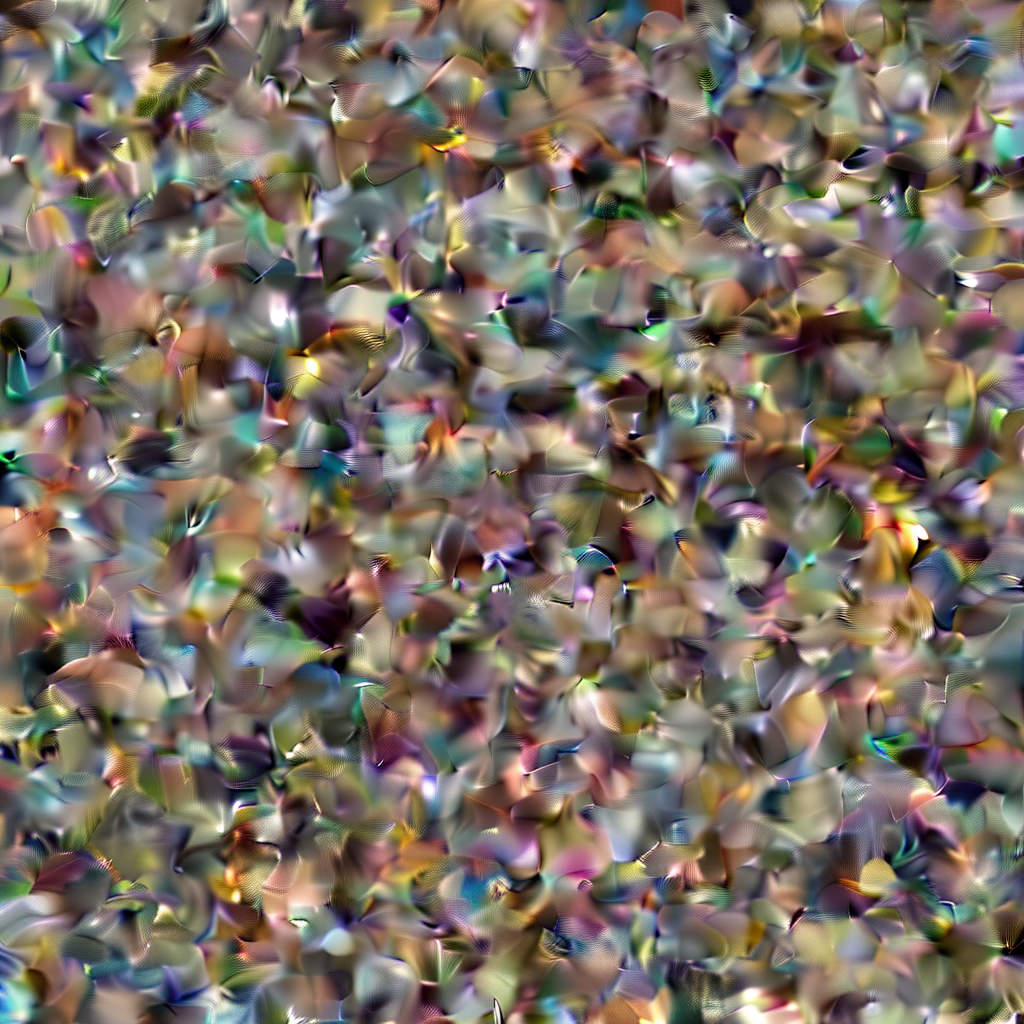

In [19]:
# batch size 1, 32 channels, height/width of 32 (=1024/32)
latent = torch.randn(
    [1, 32, 32, 32],
    dtype=dtype,
    generator=torch.manual_seed(42)
).to(device)

# fixed constant scaling_factor applied before invoking AutoEncoder
latent_to_PIL(latent / dcae.config["scaling_factor"], dcae)

In [20]:
from diffusers import AutoencoderDC, SanaTransformer2DModel

model_repo = "Efficient-Large-Model/Sana_600M_1024px_diffusers"

transformer = SanaTransformer2DModel.from_pretrained(
    model_repo,
    subfolder="transformer", 
    torch_dtype=dtype
).to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/project/6095556/jxiang27/ai4fun/ai4fun/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/495 [00:00<?, ?B/s]

transformer/diffusion_pytorch_model.safe(…):   0%|          | 0.00/2.37G [00:00<?, ?B/s]

In [22]:
def encode_prompt(prompt, tokenizer, text_encoder, max_length=50, add_special_tokens=False, **kwargs):
    # lower case prompt! took a long time to find that this is necessary: https://github.com/huggingface/diffusers/blob/e8aacda762e311505ba05ae340af23b149e37af3/src/diffusers/pipelines/sana/pipeline_sana.py#L433
    tokenizer.padding_side = "right"
    if isinstance(prompt, list):
        prompt = [p.lower().strip() for p in prompt]
    elif isinstance(prompt, str):
        prompt = prompt.lower().strip()
    else:
        raise Exception(f"Unknown prompt type {type(prompt)}")         
    prompt_tok = tokenizer(prompt, return_tensors="pt", return_attention_mask=True, padding="max_length", truncation=True, max_length=max_length, add_special_tokens=add_special_tokens).to(text_encoder.device)
    with torch.no_grad():
        prompt_encoded=text_encoder(**prompt_tok)
    return prompt_encoded.last_hidden_state, prompt_tok.attention_mask

In [40]:
prompt = "A beautiful Siss mountain landscape, photorealistic"

# Encode the prompt
prompt_encoded, prompt_atnmask = encode_prompt(prompt, tokenizer, text_encoder)

In [41]:
prompt_encoded

tensor([[[ 0.0270,  4.6250, -0.1357,  ..., -1.8281,  1.5469,  0.8594],
         [ 0.0608,  0.2285, -0.8398,  ..., -2.3125,  1.9844, -2.0312],
         [ 0.5391, -0.8672, -0.4141,  ...,  0.8906,  3.5781, -2.2188],
         ...,
         [-0.0417, -2.1875, -0.3223,  ..., -0.3965,  2.3438, -0.2734],
         [ 0.1050, -2.1719, -0.5039,  ..., -0.0192,  2.3594, -0.3262],
         [ 0.3418, -2.0156, -0.5312,  ...,  0.2285,  2.3906, -0.2500]]],
       device='cuda:0', dtype=torch.bfloat16)

In [42]:
prompt_encoded.shape  

torch.Size([1, 50, 2304])

In [43]:
prompt_atnmask

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]], device='cuda:0')

In [44]:
# Number of steps to take from noise to image
num_steps = 100

# Divide 1000 -> 0 in equally spaced steps
timesteps = torch.linspace(1000, 0, num_steps + 1)

# Noise level. 1.0 -> 0.0 in equally spaced steps
sigmas = timesteps / 1000

In [45]:
latent = torch.randn(
    [1, 32, 32, 32], 
    generator = torch.manual_seed(32)
).to(dtype).to(device)

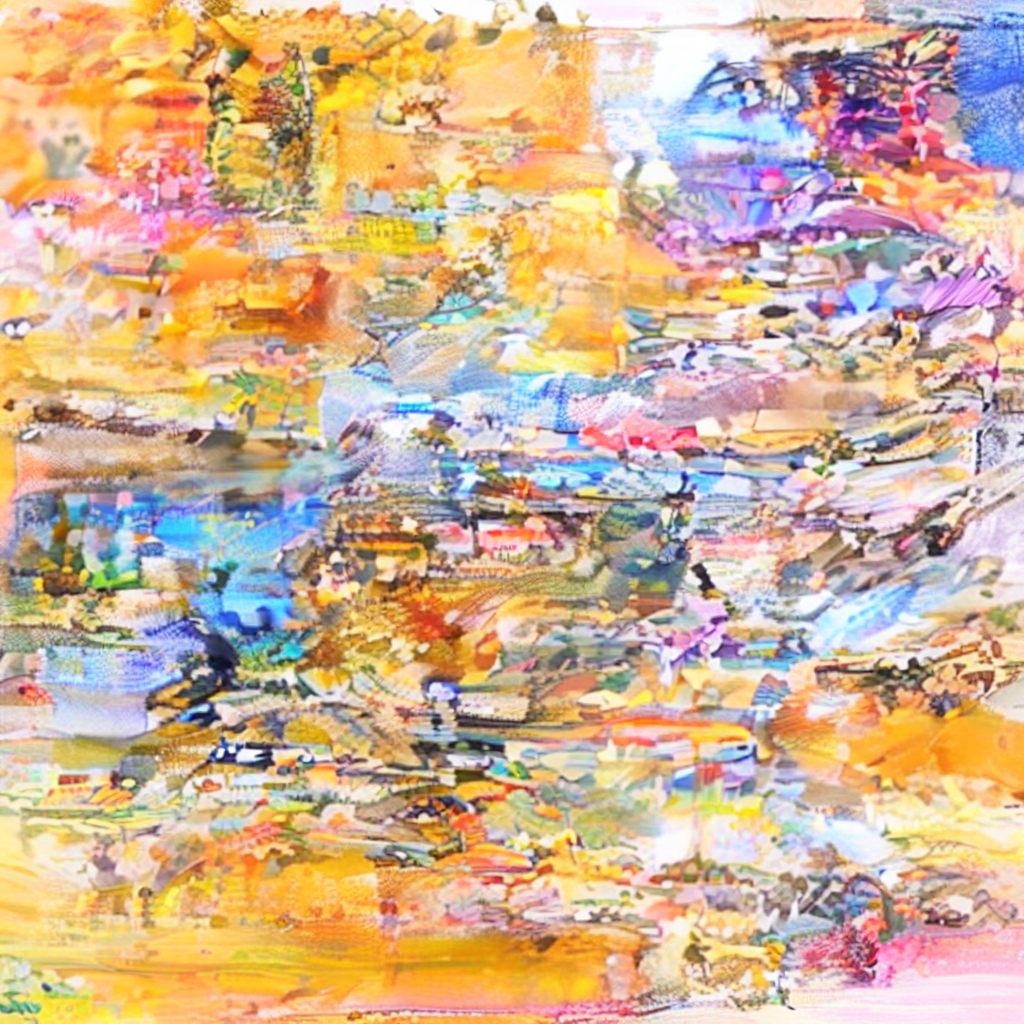

In [46]:
for t, sigma_prev, sigma_next, steps_left in zip(
    timesteps, 
    sigmas[:-1], 
    sigmas[1:], 
    range(num_steps, 0, -1)
):
    # DiT predicts noise
    with torch.no_grad():
        noise_pred = transformer(
            latent, 
            timestep=t[None].to(dcae.dtype).to(dcae.device), 
            encoder_hidden_states=prompt_encoded, 
            encoder_attention_mask=prompt_atnmask, 
            return_dict=False
        )[0]

    # Remove noise from latent
    latent = latent + (sigma_next - sigma_prev) * noise_pred 

latent_to_PIL(latent / dcae.config["scaling_factor"], dcae)